# TDSP — Plant disease **severity** (segmentation) — final notebook

**Run order:** top → bottom. First cell installs deps if needed.

**Outputs:** `output_v3_final/` (configurable) — best weights, history JSON, plots, TFLite.

**Training:** `EarlyStopping` + `ModelCheckpoint` on `val_iou_metric` + `ReduceLROnPlateau` (monitor val IoU).

**XAI:** prediction vs GT overlays + pixel error map + lightweight Grad-CAM on the last decoder conv.

In [1]:
# 0 — Dependencies
%pip install tensorflow opencv-python matplotlib scikit-learn albumentations pandas -q

import os, json, random, warnings, sys
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
import albumentations as A

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("Compute    :", gpus[0].name if gpus else "CPU")



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
TensorFlow: 2.21.0
Compute    : CPU


In [2]:
# 1 — Paths & hyperparameters
def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "crop_disease_detection").is_dir():
        return cwd
    if (cwd.parent / "crop_disease_detection").is_dir():
        return cwd.parent
    return cwd  # fallback

REPO_ROOT = find_repo_root()
SEVERITY_DIR = REPO_ROOT / "severity_analysis"
if str(SEVERITY_DIR) not in sys.path:
    sys.path.insert(0, str(SEVERITY_DIR))

BASE_PATH = REPO_ROOT / "severity_analysis" / "archive (2)" / "data" / "data"
AUG_PATH = REPO_ROOT / "severity_analysis" / "archive (2)" / "aug_data" / "aug_data"
IMG_DIR = BASE_PATH / "images"
MSK_DIR = BASE_PATH / "masks"
AUG_IMG = AUG_PATH / "images"
AUG_MSK = AUG_PATH / "masks"

OUTPUT_DIR = REPO_ROOT / "severity_analysis" / "output_v3_final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PLANT_CLASSIFIER_PATH = REPO_ROOT / "crop_disease_detection" / "models" / "best_model.keras"
LOAD_PLANT_DISEASE_ENCODER = True

IMG_SIZE = 224
BATCH_SIZE = 8
EPOCHS = 200  # EarlyStopping will cut this short
DROPOUT_RATE = 0.15
L2_WEIGHT = 1e-4
AUG_VARIANTS = 5

SEVERITY_THRESHOLDS = [5, 20, 40, 60, 100]
SEVERITY_LABELS = ["Healthy", "Low", "Moderate", "High", "Critical"]
SEVERITY_COLORS = ["#27ae60", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]

MODEL_PATH = OUTPUT_DIR / "best_severity_model_final.keras"
TFLITE_PATH = OUTPUT_DIR / "severity_model_final.tflite"
HIST_PATH = OUTPUT_DIR / "training_history_final.json"

# Set False to skip training and only evaluate / XAI / export if MODEL_PATH exists
TRAIN = True

print("REPO_ROOT          :", REPO_ROOT)
print("OUTPUT_DIR         :", OUTPUT_DIR)
print("Classifier exists  :", PLANT_CLASSIFIER_PATH.is_file())
print("TRAIN              :", TRAIN)


REPO_ROOT          : C:\Users\fadih\Desktop\ProjetPi
OUTPUT_DIR         : C:\Users\fadih\Desktop\ProjetPi\severity_analysis\output_v3_final
Classifier exists  : True
TRAIN              : True


## 2 — Data inventory & severity distribution

In [3]:
orig_imgs = sorted(f for f in os.listdir(IMG_DIR) if f.endswith(".jpg"))
orig_msks = sorted(f for f in os.listdir(MSK_DIR))
aug_imgs = sorted(f for f in os.listdir(AUG_IMG)) if AUG_IMG.is_dir() else []

inventory = pd.DataFrame(
    [
        {"Split": "Original", "Images": len(orig_imgs), "Masks": len(orig_msks)},
        {"Split": "Augmented", "Images": len(aug_imgs), "Masks": len(aug_imgs)},
        {"Split": "TOTAL", "Images": len(orig_imgs) + len(aug_imgs), "Masks": len(orig_msks) + len(aug_imgs)},
    ]
)
print(inventory.to_string(index=False))


    Split  Images  Masks
 Original     588    588
Augmented    2940   2940
    TOTAL    3528   3528


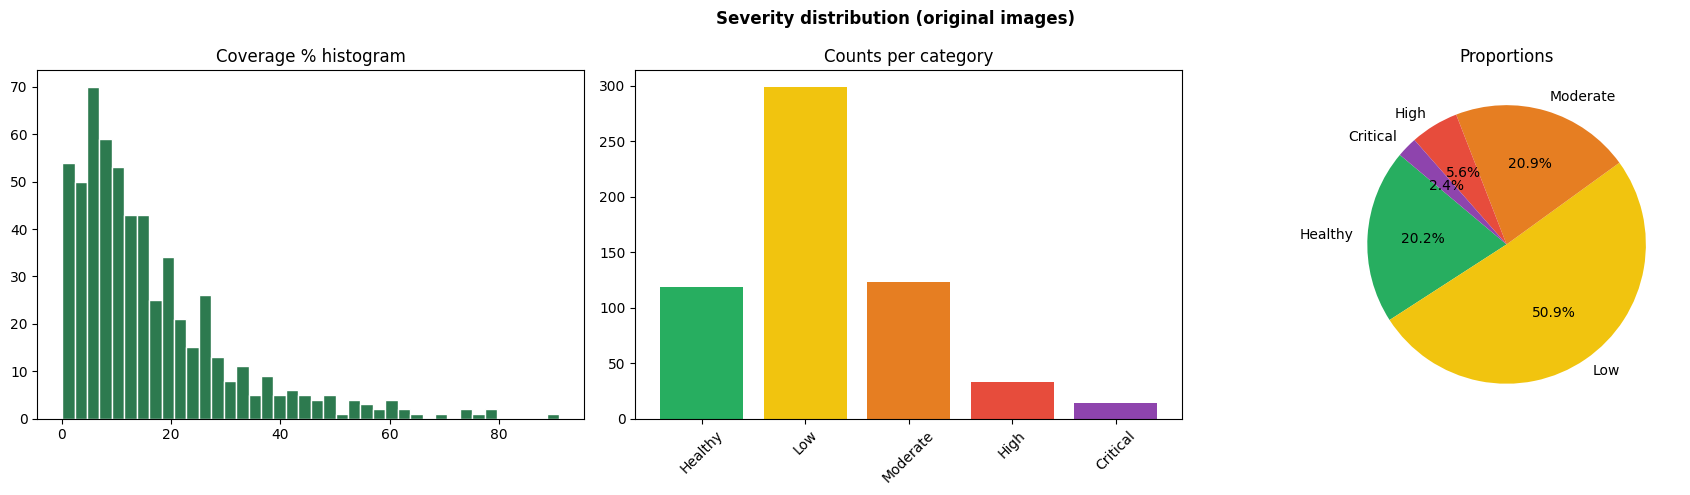

In [4]:
severity_pcts = []
for fname in orig_imgs:
    msk = cv2.imread(str(MSK_DIR / fname.replace(".jpg", ".png")), cv2.IMREAD_GRAYSCALE)
    if msk is not None:
        severity_pcts.append(float((msk > 0).sum()) / msk.size * 100)
severity_pcts = np.array(severity_pcts)


def get_cat(p):
    for i, t in enumerate(SEVERITY_THRESHOLDS):
        if p < t:
            return SEVERITY_LABELS[i]
    return SEVERITY_LABELS[-1]


cats = [get_cat(p) for p in severity_pcts]
cat_counts = pd.Series(cats).value_counts().reindex(SEVERITY_LABELS).fillna(0).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Severity distribution (original images)", fontweight="bold")
axes[0].hist(severity_pcts, bins=40, color="#2d7a4f", edgecolor="white")
axes[0].set_title("Coverage % histogram")
axes[1].bar(SEVERITY_LABELS, cat_counts, color=SEVERITY_COLORS)
axes[1].set_title("Counts per category")
axes[1].tick_params(axis="x", rotation=45)
axes[2].pie(cat_counts, labels=SEVERITY_LABELS, colors=SEVERITY_COLORS, autopct="%1.1f%%", startangle=140)
axes[2].set_title("Proportions")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "severity_distribution_final.png", dpi=150, bbox_inches="tight")
plt.show()


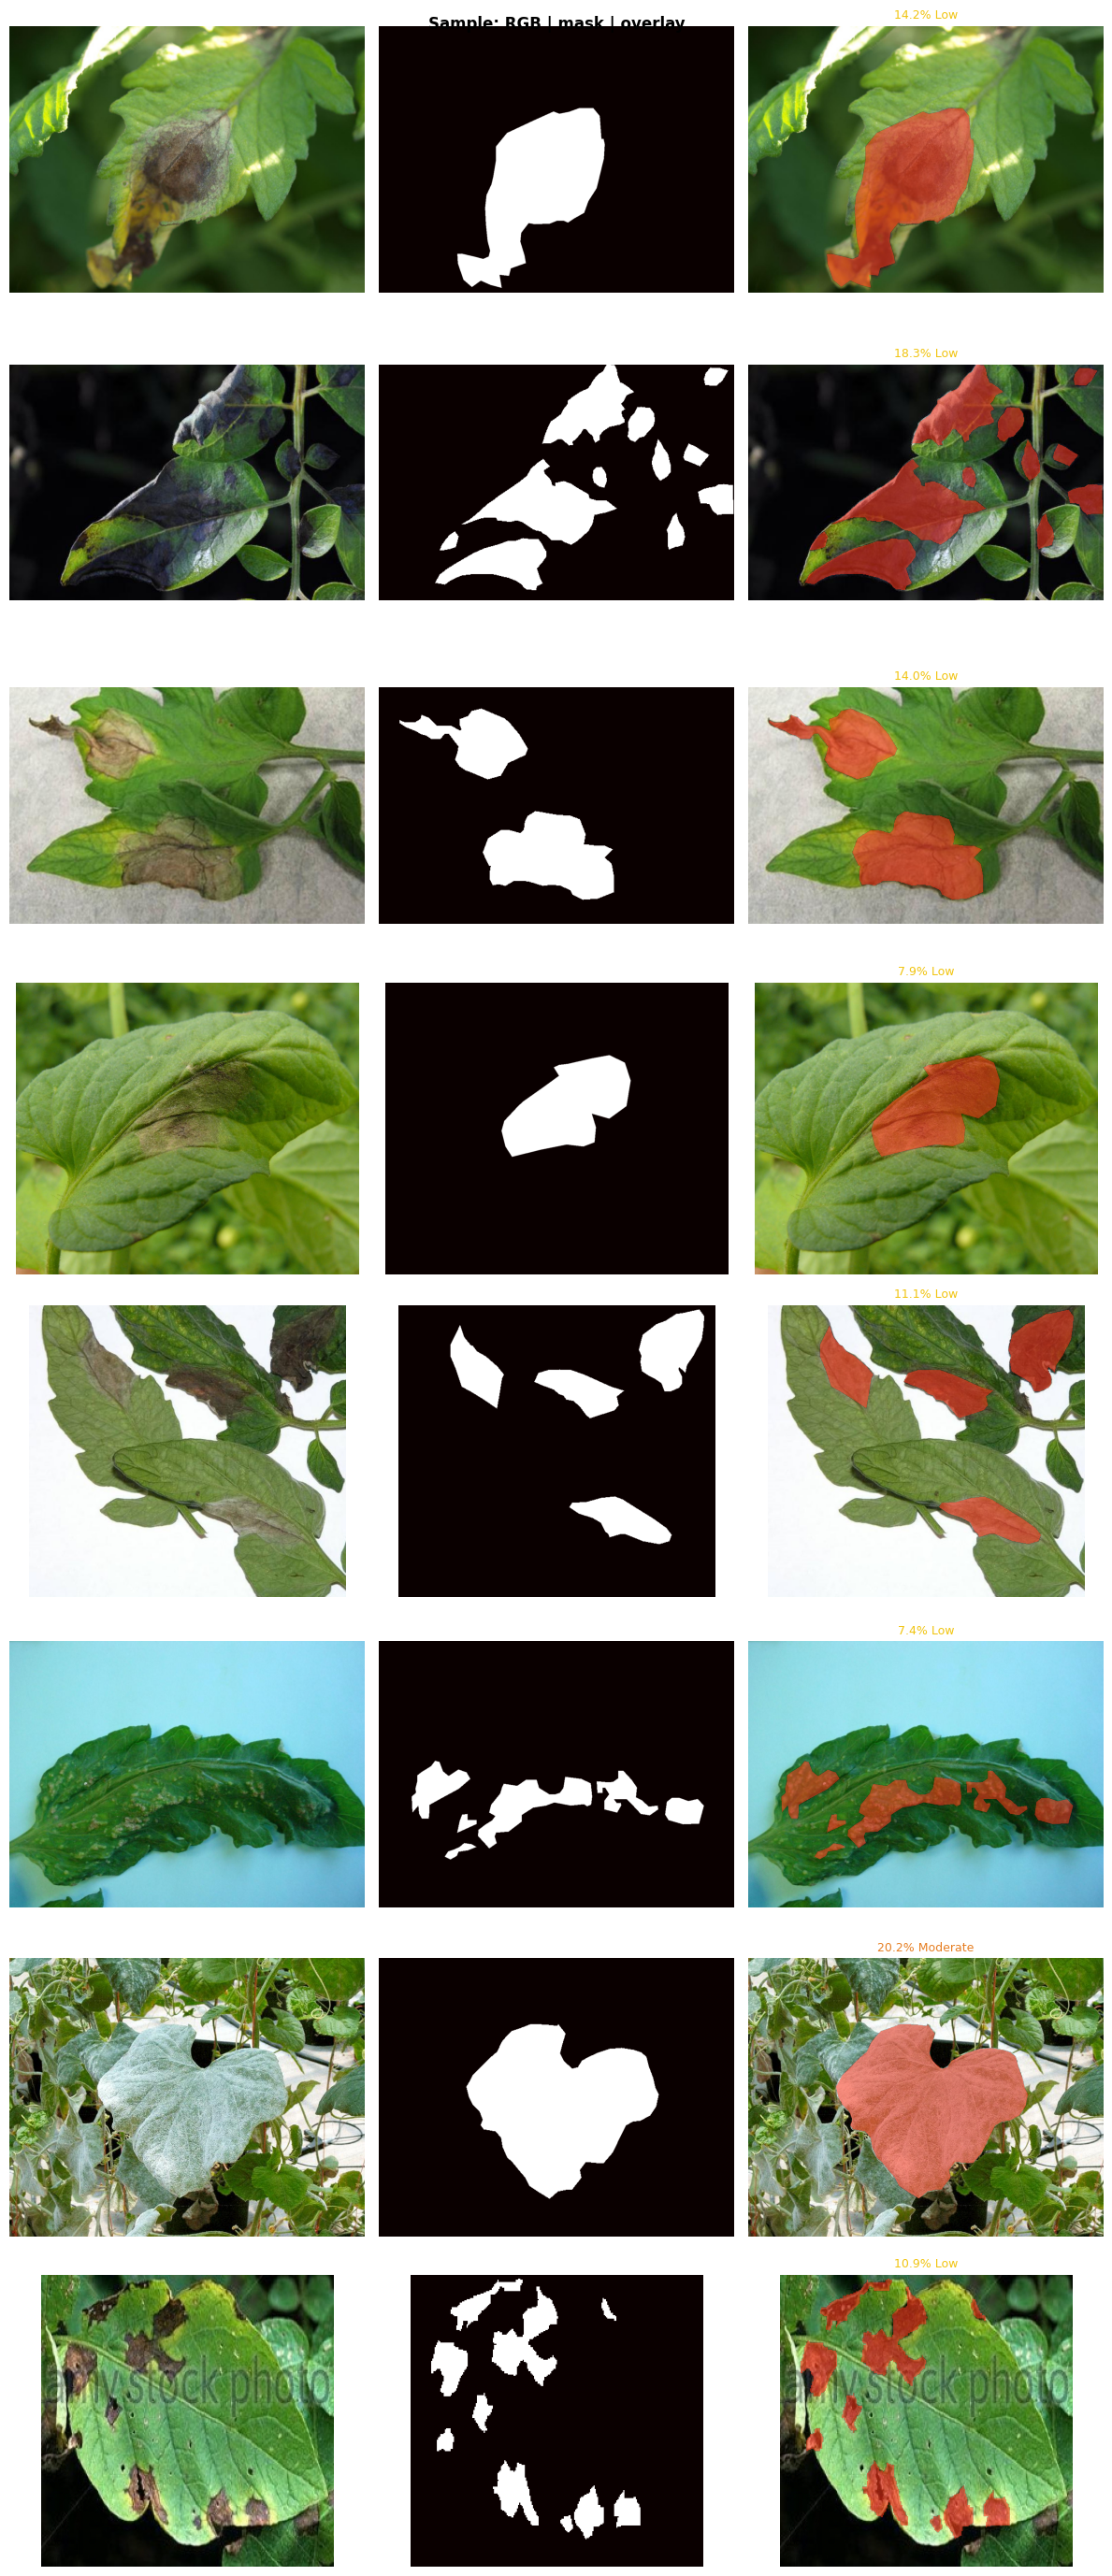

In [5]:
sample_files = random.sample(orig_imgs, min(8, len(orig_imgs)))
fig, axes = plt.subplots(len(sample_files), 3, figsize=(12, 3.5 * len(sample_files)))
if len(sample_files) == 1:
    axes = np.expand_dims(axes, 0)
fig.suptitle("Sample: RGB | mask | overlay", fontweight="bold")
for row, fname in enumerate(sample_files):
    img = cv2.cvtColor(cv2.imread(str(IMG_DIR / fname)), cv2.COLOR_BGR2RGB)
    msk = cv2.imread(str(MSK_DIR / fname.replace(".jpg", ".png")), cv2.IMREAD_GRAYSCALE)
    bm = (msk > 0).astype(np.float32)
    sev = bm.mean() * 100
    cat = get_cat(sev)
    col = SEVERITY_COLORS[SEVERITY_LABELS.index(cat)]
    axes[row, 0].imshow(img)
    axes[row, 0].axis("off")
    axes[row, 1].imshow(bm, cmap="hot", vmin=0, vmax=1)
    axes[row, 1].axis("off")
    axes[row, 2].imshow(img)
    overlay = np.zeros((*bm.shape, 4), dtype=np.float32)
    overlay[bm > 0] = [1, 0.2, 0.1, 0.55]
    axes[row, 2].imshow(overlay)
    axes[row, 2].axis("off")
    axes[row, 2].set_title(f"{sev:.1f}% {cat}", color=col, fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_grid_final.png", dpi=150, bbox_inches="tight")
plt.show()


In [6]:
all_ids = sorted(os.path.splitext(f)[0] for f in orig_imgs)
train_ids, temp_ids = train_test_split(all_ids, test_size=0.30, random_state=SEED)
val_ids, test_ids = train_test_split(temp_ids, test_size=0.50, random_state=SEED)

assert not set(train_ids) & set(val_ids)
assert not set(train_ids) & set(test_ids)
assert not set(val_ids) & set(test_ids)

id_to_sev = {os.path.splitext(f)[0]: p for f, p in zip(orig_imgs, severity_pcts)}
print(
    f"Train {len(train_ids)} orig → {len(train_ids)*(1+AUG_VARIANTS)} with aug | "
    f"Val {len(val_ids)} | Test {len(test_ids)}"
)


Train 411 orig → 2466 with aug | Val 88 | Test 89


In [7]:
def load_pair(img_path, msk_path, img_size):
    img = cv2.imread(str(img_path))
    if img is None:
        return None, None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype(np.float32) / 255.0
    msk = cv2.imread(str(msk_path), cv2.IMREAD_GRAYSCALE)
    if msk is None:
        return None, None
    msk = cv2.resize(msk, (img_size, img_size), interpolation=cv2.INTER_NEAREST)
    msk = np.expand_dims((msk > 0).astype(np.float32), -1)
    return img, msk


def load_split(ids, include_aug=True):
    images, masks, skipped = [], [], 0
    for id_ in ids:
        ip = IMG_DIR / f"{id_}.jpg"
        mp = MSK_DIR / f"{id_}.png"
        img, msk = load_pair(ip, mp, IMG_SIZE)
        if img is None:
            skipped += 1
            continue
        images.append(img)
        masks.append(msk)
        if include_aug and AUG_IMG.is_dir():
            for k in range(AUG_VARIANTS):
                aip = AUG_IMG / f"{id_}_{k}.jpg"
                amp = AUG_MSK / f"{id_}_{k}.png"
                if not aip.exists():
                    continue
                img, msk = load_pair(aip, amp, IMG_SIZE)
                if img is not None:
                    images.append(img)
                    masks.append(msk)
    print(f"  loaded {len(images)} samples, skipped {skipped}")
    return np.asarray(images, np.float32), np.asarray(masks, np.float32)


print("Train…")
X_train, Y_train = load_split(train_ids, include_aug=True)
print("Val…")
X_val, Y_val = load_split(val_ids, include_aug=False)
print("Test…")
X_test, Y_test = load_split(test_ids, include_aug=False)
print(X_train.shape, X_val.shape, X_test.shape)


Train…
  loaded 2466 samples, skipped 0
Val…
  loaded 88 samples, skipped 0
Test…
  loaded 89 samples, skipped 0
(2466, 224, 224, 3) (88, 224, 224, 3) (89, 224, 224, 3)


In [8]:
aug_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.RandomRotate90(p=0.5),
        A.Affine(
            translate_percent={"x": (-0.05, 0.05), "y": (-0.05, 0.05)},
            scale=(0.9, 1.1),
            rotate=(-15, 15),
            p=0.5,
        ),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
        A.GaussNoise(std_range=(0.02, 0.09), p=0.3),
        A.ElasticTransform(alpha=1, sigma=10, p=0.2),
    ]
)


class AugmentedDataGenerator(keras.utils.Sequence):
    def __init__(self, X, Y, batch_size=8, augment=False, shuffle=True):
        self.X, self.Y = X, Y
        self.batch_size = batch_size
        self.augment = augment
        self.shuffle = shuffle
        self.indices = np.arange(len(X))
        if shuffle:
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        bi = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        bX, bY = self.X[bi].copy(), self.Y[bi].copy()
        if self.augment:
            for i in range(len(bX)):
                img = (bX[i] * 255).astype(np.uint8)
                msk = (bY[i, :, :, 0] * 255).astype(np.uint8)
                out = aug_transform(image=img, mask=msk)
                bX[i] = out["image"].astype(np.float32) / 255.0
                bY[i, :, :, 0] = (out["mask"] > 127).astype(np.float32)
        return bX, bY

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


train_gen = AugmentedDataGenerator(X_train, Y_train, BATCH_SIZE, augment=True, shuffle=True)
val_gen = AugmentedDataGenerator(X_val, Y_val, BATCH_SIZE, augment=False, shuffle=False)
print("batches train", len(train_gen), "val", len(val_gen))


batches train 309 val 11


## 3 — Model: Attention U-Net + losses + training callbacks

In [9]:
def iou_metric(y_true, y_pred):
    y_p = tf.cast(y_pred > 0.5, tf.float32)
    inter = tf.reduce_sum(y_true * y_p)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_p) - inter
    return (inter + 1e-7) / (union + 1e-7)


def dice_loss(y_true, y_pred):
    sm = 1e-7
    yt = tf.reshape(y_true, [-1])
    yp = tf.reshape(y_pred, [-1])
    return 1.0 - (2.0 * tf.reduce_sum(yt * yp) + sm) / (tf.reduce_sum(yt) + tf.reduce_sum(yp) + sm)


def combined_loss(y_true, y_pred):
    return dice_loss(y_true, y_pred) + tf.reduce_mean(
        keras.losses.binary_crossentropy(y_true, y_pred)
    )


def attention_gate(x, g, filters):
    x1 = layers.Conv2D(filters, 1, padding="same")(x)
    g1 = layers.Conv2D(filters, 1, padding="same")(g)
    combined = layers.Activation("relu")(layers.Add()([x1, g1]))
    psi = layers.Conv2D(1, 1, activation="sigmoid", padding="same")(combined)
    return layers.Multiply()([x, psi])


def decoder_block(x, skip, filters):
    x = layers.UpSampling2D((2, 2))(x)
    skip = attention_gate(skip, x, filters)
    x = layers.Concatenate()([x, skip])
    reg = regularizers.l2(L2_WEIGHT)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu", kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu", kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    return x


def build_mobilenetv3_attention_unet(input_shape=(224, 224, 3)):
    base_model = tf.keras.applications.MobileNetV3Large(
        input_shape=input_shape, include_top=False, weights="imagenet"
    )
    base_model.trainable = True
    s1 = base_model.get_layer("expanded_conv_project").output
    s2 = base_model.get_layer("expanded_conv_2_add").output
    s3 = base_model.get_layer("expanded_conv_5_add").output
    s4 = base_model.get_layer("expanded_conv_11_add").output
    bridge = base_model.get_layer("expanded_conv_14_add").output
    d1 = decoder_block(bridge, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)
    x = layers.UpSampling2D((2, 2))(d4)
    reg_out = regularizers.l2(L2_WEIGHT)
    x = layers.Conv2D(
        32,
        3,
        padding="same",
        activation="relu",
        kernel_regularizer=reg_out,
        name="decoder_last_conv",
    )(x)
    x = layers.Dropout(DROPOUT_RATE * 0.5)(x)
    output = layers.Conv2D(1, 1, activation="sigmoid", name="mask_output")(x)
    return tf.keras.Model(inputs=base_model.input, outputs=output, name="MobileNetV3_Attention_UNet")


model = build_mobilenetv3_attention_unet((IMG_SIZE, IMG_SIZE, 3))
if LOAD_PLANT_DISEASE_ENCODER:
    from plant_encoder_transfer import apply_plant_disease_encoder_to_unet

    ok = apply_plant_disease_encoder_to_unet(model, str(PLANT_CLASSIFIER_PATH))
    print("Encoder transfer:", "OK" if ok else "skipped (ImageNet only)")

model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss=combined_loss,
    metrics=["accuracy", iou_metric],
)
model.summary()


  [encoder transfer] copied 106 MobileNet layers (2 name/shape skips)
Encoder transfer: OK


Model: "MobileNetV3_Attention_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 9,259,653 (35.32 MB)

 Trainable params: 9,233,333 (35.22 MB)

 Non-trainable params: 26,320 (102.81 KB)

In [10]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        str(MODEL_PATH),
        monitor="val_iou_metric",
        mode="max",
        save_best_only=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_iou_metric",
        mode="max",
        factor=0.5,
        patience=6,
        min_lr=1e-7,
        verbose=1,
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_iou_metric",
        mode="max",
        patience=15,
        restore_best_weights=True,
        verbose=1,
    ),
]

if TRAIN:
    print(f"Training up to {EPOCHS} epochs (EarlyStopping patience=15 on val_iou_metric)…")
    history = model.fit(
        train_gen,
        epochs=EPOCHS,
        validation_data=val_gen,
        callbacks=callbacks,
        verbose=1,
    )
    with open(HIST_PATH, "w") as f:
        json.dump({k: [float(v) for v in vals] for k, vals in history.history.items()}, f, indent=2)
    print("History saved:", HIST_PATH)
else:
    if MODEL_PATH.is_file():
        model = keras.models.load_model(
            str(MODEL_PATH),
            custom_objects={
                "combined_loss": combined_loss,
                "dice_loss": dice_loss,
                "iou_metric": iou_metric,
            },
            compile=False,
            safe_mode=False,
        )
        model.compile(
            optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
            loss=combined_loss,
            metrics=["accuracy", iou_metric],
        )
        print("Loaded model from", MODEL_PATH)
    else:
        raise FileNotFoundError("TRAIN=False but no checkpoint at " + str(MODEL_PATH))


Training up to 200 epochs (EarlyStopping patience=15 on val_iou_metric)…
Epoch 1/200
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8296 - iou_metric: 0.4381 - loss: 1.0490
Epoch 1: val_iou_metric improved from None to 0.00040, saving model to C:\Users\fadih\Desktop\ProjetPi\severity_analysis\output_v3_final\best_severity_model_final.keras

Epoch 1: finished saving model to C:\Users\fadih\Desktop\ProjetPi\severity_analysis\output_v3_final\best_severity_model_final.keras
309/309 ━━━━━━━━━━━━━━━━━━━━ 380s 1s/step - accuracy: 0.8896 - iou_metric: 0.5292 - loss: 0.8501 - val_accuracy: 0.8504 - val_iou_metric: 4.0389e-04 - val_loss: 2.2298 - learning_rate: 1.0000e-04
Epoch 2/200
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 890ms/step - accuracy: 0.9276 - iou_metric: 0.6301 - loss: 0.6626
Epoch 2: val_iou_metric improved from 0.00040 to 0.22501, saving model to C:\Users\fadih\Desktop\ProjetPi\severity_analysis\output_v3_final\best_severity_model_final.keras

Epoch 2: finished saving model to C:\Us

## 4 — Learning curves & test metrics

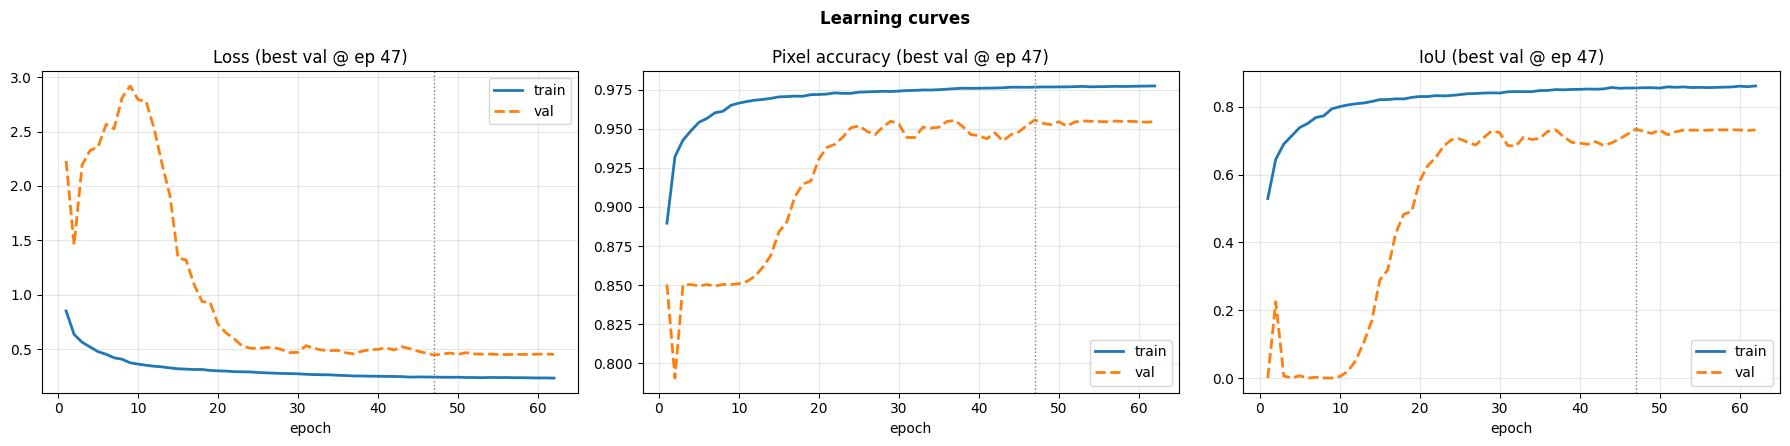

Best val IoU epoch 47: train IoU=0.8553 val IoU=0.7341


In [11]:
with open(HIST_PATH) as f:
    hist = json.load(f)
epochs_ran = np.arange(1, len(hist["loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
fig.suptitle("Learning curves", fontweight="bold")
pairs = [
    ("loss", "val_loss", "Loss", "min"),
    ("accuracy", "val_accuracy", "Pixel accuracy", "max"),
    ("iou_metric", "val_iou_metric", "IoU", "max"),
]
for ax, (tk, vk, title, how) in zip(axes, pairs):
    ax.plot(epochs_ran, hist[tk], label="train", lw=2)
    ax.plot(epochs_ran, hist[vk], "--", label="val", lw=2)
    if how == "min":
        i = int(np.argmin(hist[vk]))
    else:
        i = int(np.argmax(hist[vk]))
    ax.axvline(i + 1, color="gray", ls=":", lw=1)
    ax.set_title(f"{title} (best val @ ep {i+1})")
    ax.set_xlabel("epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "learning_curves_final.png", dpi=150, bbox_inches="tight")
plt.show()

be = int(np.argmax(hist["val_iou_metric"]))
print(
    f"Best val IoU epoch {be+1}: train IoU={hist['iou_metric'][be]:.4f} val IoU={hist['val_iou_metric'][be]:.4f}"
)


Loss goes down on train and val; train stays lower → some overfitting, but val loss still improves overall. Pixel accuracy is high on both (many background pixels). IoU is the important curve: val IoU rises after noisy early epochs, then stabilizes ~0.70–0.73; the dotted line (epoch 47) is the best val IoU — good place to stop and use those weights.

In [12]:
def dice_np(y_true, y_pred, thr=0.5):
    yt = (y_true.ravel() > thr).astype(np.float32)
    yp = (y_pred.ravel() > thr).astype(np.float32)
    inter = np.sum(yt * yp)
    return (2 * inter + 1e-7) / (np.sum(yt) + np.sum(yp) + 1e-7)


def iou_np(y_true, y_pred, thr=0.5):
    yt = (y_true.ravel() > thr).astype(np.float32)
    yp = (y_pred.ravel() > thr).astype(np.float32)
    inter = np.sum(yt * yp)
    union = np.sum(yt) + np.sum(yp) - inter
    return (inter + 1e-7) / (union + 1e-7)


print("--- Test set (keras) ---")
model.evaluate(X_test, Y_test, batch_size=BATCH_SIZE, verbose=1)

preds = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)
ious, dices = [], []
for i in range(len(X_test)):
    ious.append(iou_np(Y_test[i], preds[i]))
    dices.append(dice_np(Y_test[i], preds[i]))
print(f"Mean test IoU:  {np.mean(ious):.4f} ± {np.std(ious):.4f}")
print(f"Mean test Dice: {np.mean(dices):.4f} ± {np.std(dices):.4f}")


--- Test set (keras) ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.9384 - iou_metric: 0.7191 - loss: 0.5668
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 345ms/step
Mean test IoU:  0.6943 ± 0.1861
Mean test Dice: 0.8023 ± 0.1611


In [21]:
import json
import numpy as np
import pandas as pd

name = getattr(model, "name", "MobileNetV3_Attention_UNet")

with open(HIST_PATH) as f:
    hist = json.load(f)
be = int(np.argmax(hist["val_iou_metric"]))

# Accuracy from history (train / val) at best epoch
acc_tr = float(hist["accuracy"][be])
acc_va = float(hist["val_accuracy"][be])

# Test: keras evaluate
ev = model.evaluate(X_test, Y_test, batch_size=BATCH_SIZE, verbose=0)
vals = list(ev)
nms = list(model.metrics_names)
# loss, accuracy, iou_metric — take by name when possible
ed = dict(zip(nms, vals))
acc_te = float(ed.get("accuracy", vals[1] if len(vals) > 1 else vals[0]))


def mean_iou_dice(X, Y):
    p = model.predict(X, batch_size=BATCH_SIZE, verbose=0)
    ious = [iou_np(Y[i], p[i]) for i in range(len(X))]
    dices = [dice_np(Y[i], p[i]) for i in range(len(X))]
    return float(np.mean(ious)), float(np.mean(dices))

iou_tr, dice_tr = mean_iou_dice(X_train, Y_train)
iou_va, dice_va = mean_iou_dice(X_val, Y_val)
iou_te, dice_te = mean_iou_dice(X_test, Y_test)

print("Model:", name)
df = pd.DataFrame(
    {
        "Train": [acc_tr, iou_tr, dice_tr],
        "Validation": [acc_va, iou_va, dice_va],
        "Test": [acc_te, iou_te, dice_te],
    },
    index=["Accuracy", "IoU (mean per image)", "Dice (mean per image)"],
)
df = df.round(6)
display(df)

Model: MobileNetV3_Attention_UNet


,Train,Validation,Test
Accuracy,0.976620,0.955646,0.938414
IoU (mean per image),0.827795,0.711571,0.694350
Dice (mean per image),0.899411,0.817526,0.802253


## 5 — XAI: overlays, error maps, Grad-CAM

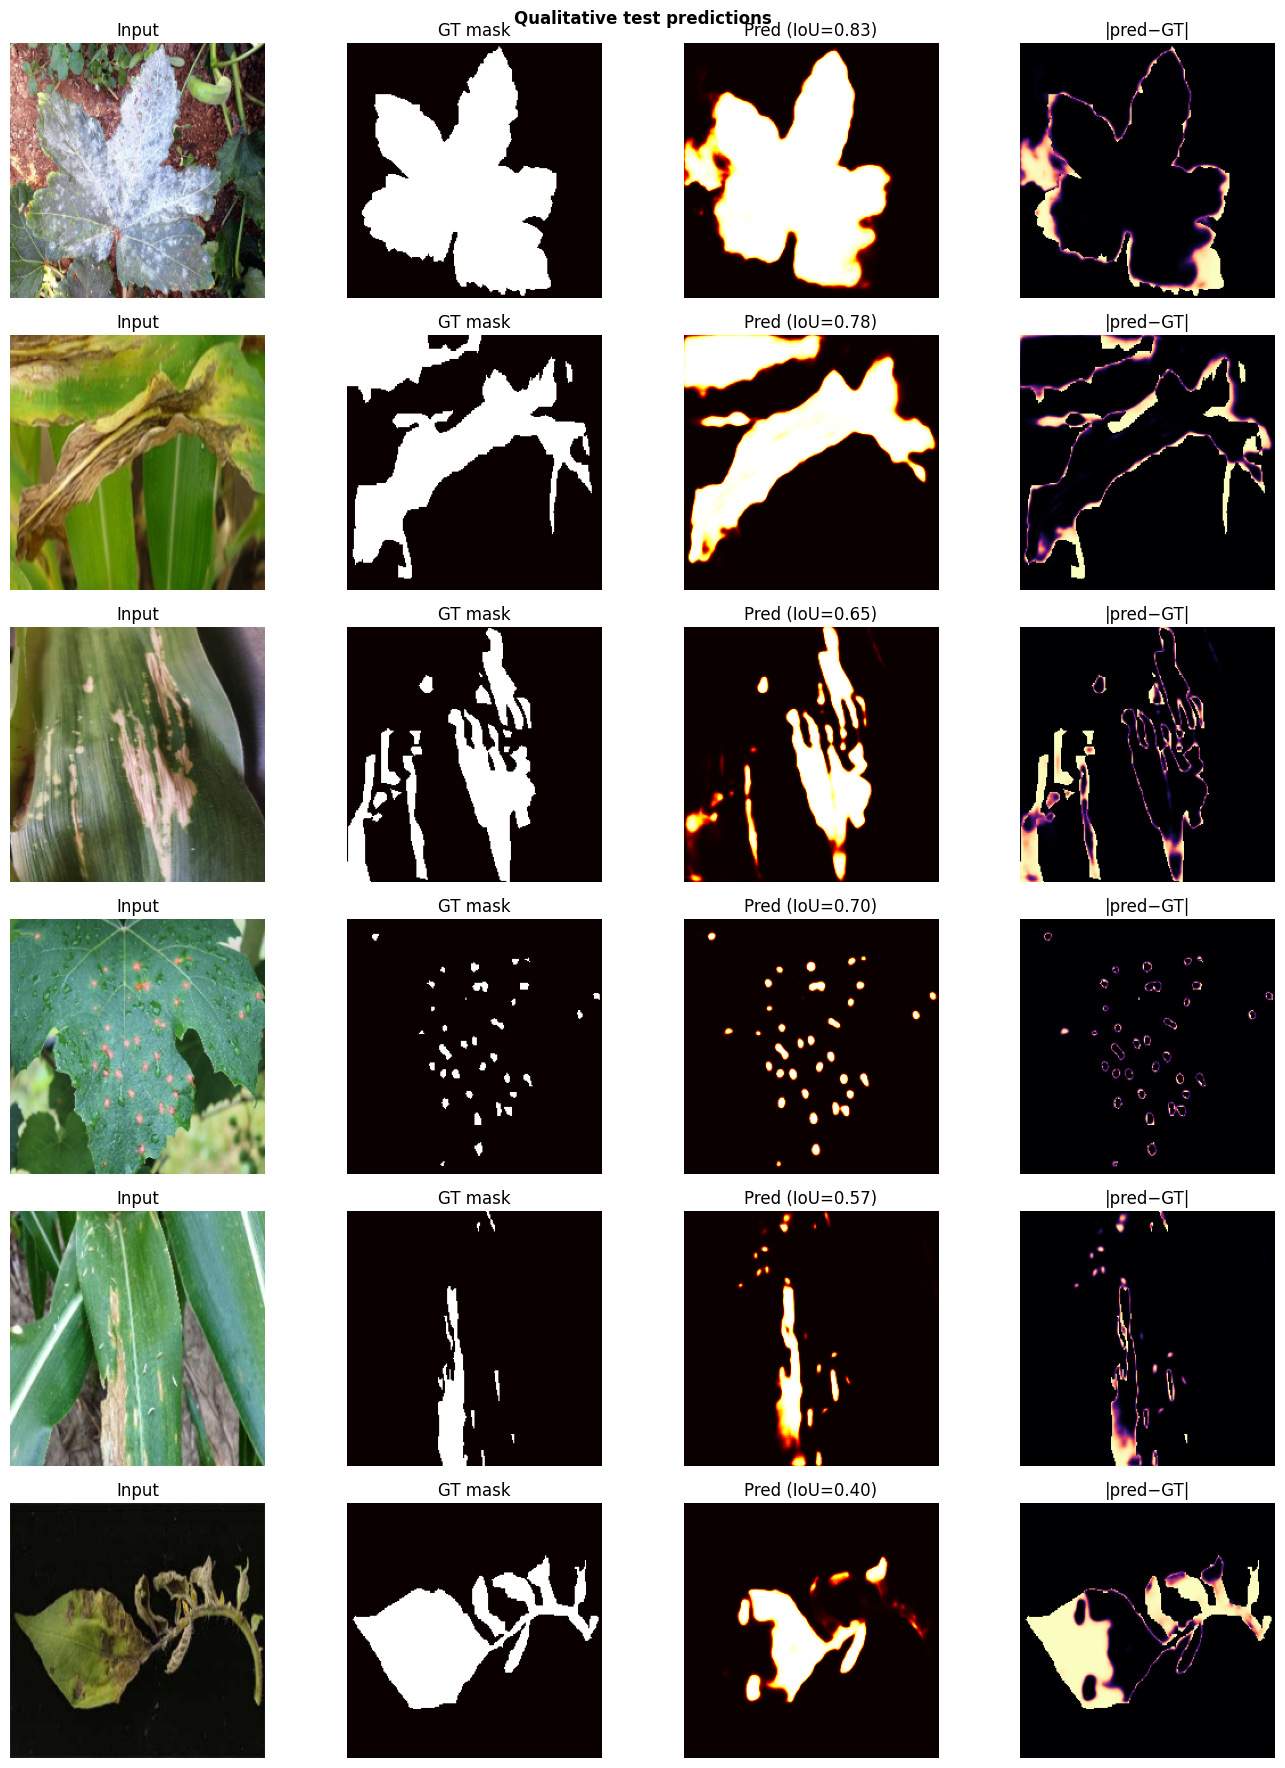

In [13]:
n_show = min(6, len(X_test))
fig, axes = plt.subplots(n_show, 4, figsize=(14, 3 * n_show))
if n_show == 1:
    axes = np.expand_dims(axes, 0)
preds = model.predict(X_test[:n_show], batch_size=BATCH_SIZE, verbose=0)
for i in range(n_show):
    gt = Y_test[i, :, :, 0]
    pr = preds[i, :, :, 0]
    err = np.abs(pr - gt)
    axes[i, 0].imshow(X_test[i])
    axes[i, 0].set_title("Input")
    axes[i, 1].imshow(gt, cmap="hot", vmin=0, vmax=1)
    axes[i, 1].set_title("GT mask")
    axes[i, 2].imshow(pr, cmap="hot", vmin=0, vmax=1)
    axes[i, 2].set_title(f"Pred (IoU={iou_np(Y_test[i], preds[i]):.2f})")
    axes[i, 3].imshow(err, cmap="magma", vmin=0, vmax=1)
    axes[i, 3].set_title("|pred−GT|")
    for j in range(4):
        axes[i, j].axis("off")
plt.suptitle("Qualitative test predictions", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xai_overlays_final.png", dpi=150, bbox_inches="tight")
plt.show()


Each row compares the real disease mask (GT) to the model mask (Pred). The IoU is overlap quality (higher = better). |Pred−GT| shows mistakes (bright = wrong). The model finds the diseased regions well on easy cases; edges and small or faint lesions are harder, so IoU drops.

12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 229ms/step


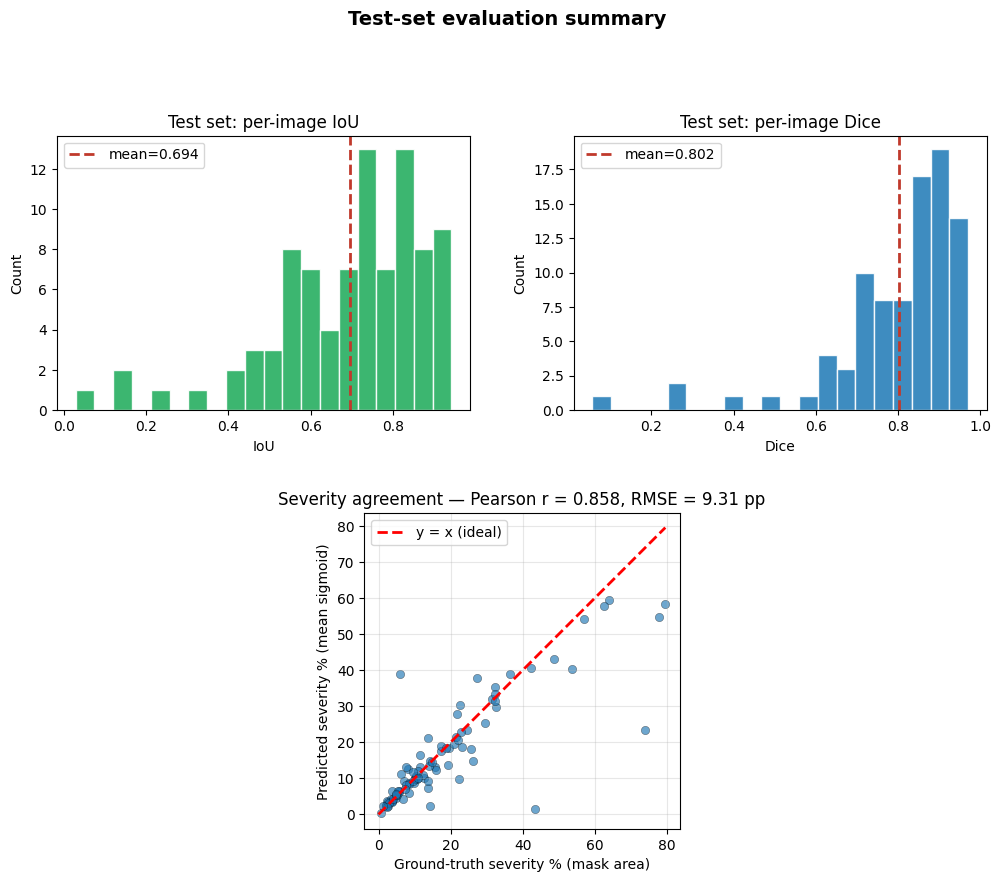

Saved: C:\Users\fadih\Desktop\ProjetPi\severity_analysis\output_v3_final\evaluation_presentation_panel.png


In [17]:
# --- Extra evaluation plots (for slides) — uses FULL test predictions ---

preds_eval = model.predict(X_test, batch_size=BATCH_SIZE, verbose=1)

gt_sev = np.array([float(Y_test[i].mean()) * 100.0 for i in range(len(X_test))])
pred_sev = np.array([float(preds_eval[i].mean()) * 100.0 for i in range(len(X_test))])
rmse = float(np.sqrt(np.mean((gt_sev - pred_sev) ** 2)))
r = float(np.corrcoef(gt_sev, pred_sev)[0, 1])

fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.15], hspace=0.35, wspace=0.25)
ax_iou = fig.add_subplot(gs[0, 0])
ax_dice = fig.add_subplot(gs[0, 1])
ax_sc = fig.add_subplot(gs[1, :])

# Recompute per-image IoU/Dice with preds_eval (same as test cell)
ious_e, dices_e = [], []
for i in range(len(X_test)):
    ious_e.append(iou_np(Y_test[i], preds_eval[i]))
    dices_e.append(dice_np(Y_test[i], preds_eval[i]))

ax_iou.hist(ious_e, bins=20, color="#27ae60", edgecolor="white", alpha=0.9)
ax_iou.axvline(np.mean(ious_e), color="#c0392b", ls="--", lw=2, label=f"mean={np.mean(ious_e):.3f}")
ax_iou.set_title("Test set: per-image IoU")
ax_iou.set_xlabel("IoU")
ax_iou.set_ylabel("Count")
ax_iou.legend()

ax_dice.hist(dices_e, bins=20, color="#2980b9", edgecolor="white", alpha=0.9)
ax_dice.axvline(np.mean(dices_e), color="#c0392b", ls="--", lw=2, label=f"mean={np.mean(dices_e):.3f}")
ax_dice.set_title("Test set: per-image Dice")
ax_dice.set_xlabel("Dice")
ax_dice.set_ylabel("Count")
ax_dice.legend()

lim = max(float(gt_sev.max()), float(pred_sev.max()), 1.0)
ax_sc.scatter(gt_sev, pred_sev, alpha=0.65, edgecolors="k", linewidths=0.3)
ax_sc.plot([0, lim], [0, lim], "r--", lw=2, label="y = x (ideal)")
ax_sc.set_xlabel("Ground-truth severity % (mask area)")
ax_sc.set_ylabel("Predicted severity % (mean sigmoid)")
ax_sc.set_title(f"Severity agreement — Pearson r = {r:.3f}, RMSE = {rmse:.2f} pp")
ax_sc.set_aspect("equal", adjustable="box")
ax_sc.legend(loc="upper left")
ax_sc.grid(True, alpha=0.3)

fig.suptitle("Test-set evaluation summary", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()

out_eval = OUTPUT_DIR / "evaluation_presentation_panel.png"
plt.savefig(out_eval, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", out_eval)

The model segments disease well on average (mean IoU ~0.69, mean Dice ~0.80), with most test images in the mid–high range and some harder cases with lower overlap. The scatter shows that predicted severity % tracks ground-truth severity quite closely (r ≈ 0.86), with typical error around 9 percentage points; most points lie near the diagonal, aside from a few outliers where prediction and truth disagree more.

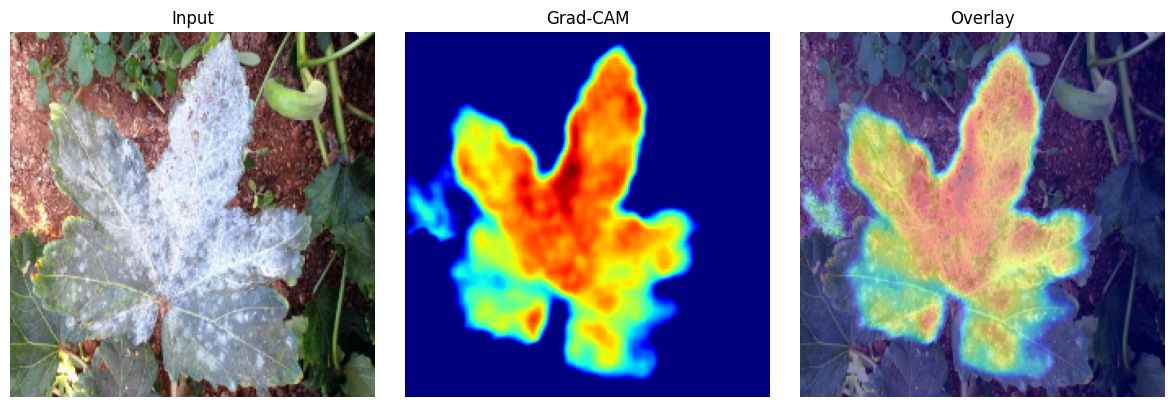

In [14]:
# Grad-CAM on decoder_last_conv (importance map for predicted mask mass)


def grad_cam_heatmap(model, img_batch_1, layer_name="decoder_last_conv"):
    # img_batch_1 shape: (1, H, W, 3)
    grad_model = keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output],
    )
    with tf.GradientTape() as tape:
        conv_out, pred = grad_model(img_batch_1, training=False)
        loss = tf.reduce_mean(pred)
    grads = tape.gradient(loss, conv_out)
    w = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)
    cam = tf.nn.relu(tf.reduce_sum(w * conv_out, axis=-1, keepdims=True))
    cam = tf.image.resize(cam, [IMG_SIZE, IMG_SIZE])
    cam = cam[0, :, :, 0]
    cmin, cmax = tf.reduce_min(cam), tf.reduce_max(cam)
    cam = (cam - cmin) / (cmax - cmin + 1e-8)
    return cam.numpy()


idx = 0
img = X_test[idx : idx + 1]
heat = grad_cam_heatmap(model, img)
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(X_test[idx])
ax[0].set_title("Input")
ax[1].imshow(heat, cmap="jet")
ax[1].set_title("Grad-CAM")
ax[2].imshow(X_test[idx])
ax[2].imshow(heat, cmap="jet", alpha=0.45)
ax[2].set_title("Overlay")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "xai_gradcam_final.png", dpi=150, bbox_inches="tight")
plt.show()


The heatmap shows where the model focuses to build the disease mask. Warm colors = important; cold/dark = ignored. On your image, heat is on the diseased leaf, not the background — so the model uses symptoms on the leaf, not the soil.

## 6 — TFLite export (mobile)

In [15]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
TFLITE_PATH.write_bytes(tflite_model)
print("Wrote", TFLITE_PATH, "bytes", TFLITE_PATH.stat().st_size)


INFO:tensorflow:Assets written to: C:\Users\fadih\AppData\Local\Temp\tmpe9pzsuao\assets


INFO:tensorflow:Assets written to: C:\Users\fadih\AppData\Local\Temp\tmpe9pzsuao\assets


Saved artifact at 'C:\Users\fadih\AppData\Local\Temp\tmpe9pzsuao'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 224, 224, 1), dtype=tf.float32, name=None)
Captures:
  2678538457488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2678538455760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2678538456528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2678538456720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2678538456336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2678538455568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2678538460368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2678538455184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2678538456144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2678538454608: TensorSpec(shape=(), dtype=tf.resource, name=Non